# Graph transcription and plotting
This notebook loads the manually transcribed edge list at `data/extracted_edge_list.csv`, builds a directed NetworkX graph, computes a spring layout with safe fallbacks and overlap resolution, and displays the graph inline.

In [23]:
# Imports and settings
%matplotlib inline
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from pathlib import Path
import math
import random

In [24]:
# Load transcribed CSV and build graph (robust path)
p = Path('data/extracted_edge_list.csv')
if not p.exists():
    p = Path('../data/extracted_edge_list.csv')
df = pd.read_csv(p)
G = nx.DiGraph()
for _, row in df.iterrows():
    u = int(row['u'])
    v = int(row['v'])
    try:
        w = int(row['weight']) if not pd.isna(row['weight']) else None
    except Exception:
        w = row['weight'] if not pd.isna(row['weight']) else None
    label = row['label'] if not pd.isna(row['label']) else ''
    G.add_node(u)
    G.add_node(v)
    G.add_edge(u, v, weight=w, label=label)
print('Loaded', len(df), 'rows from', p)
print('nodes, edges:', G.number_of_nodes(), G.number_of_edges())

Loaded 49 rows from ..\data\extracted_edge_list.csv
nodes, edges: 43 49


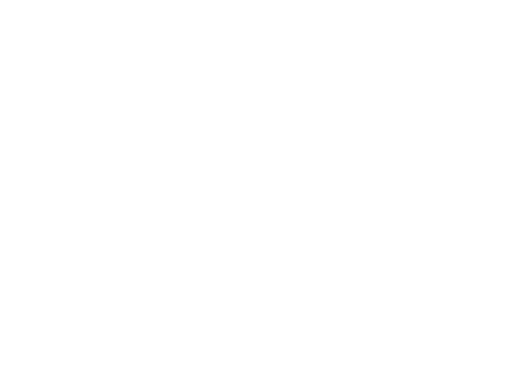

In [25]:
# Compute layout, resolve overlaps (via selecting best spring k) and display inline
n = max(1, G.number_of_nodes())

# Try several spring 'k' scales and pick the layout with maximum minimum pairwise distance
base_k = 1.0 / math.sqrt(n)
best_pos = None
best_min = -1.0
for attempt in range(6):
    k_try = base_k * (1.6 ** attempt)
    try:
        pos_try = nx.spring_layout(G, seed=42, k=k_try, iterations=400)
    except Exception:
        continue
    # normalize to [0,1]
    xs = [xy[0] for xy in pos_try.values()]
    ys = [xy[1] for xy in pos_try.values()]
    minx, maxx = min(xs), max(xs)
    miny, maxy = min(ys), max(ys)
    rgx = maxx - minx if maxx != minx else 1.0
    rgy = maxy - miny if maxy != miny else 1.0
    margin = 0.05
    for nnode, (x, y) in pos_try.items():
        nx0 = (x - minx) / rgx
        ny0 = (y - miny) / rgy
        pos_try[nnode] = (margin + nx0 * (1 - 2 * margin), margin + ny0 * (1 - 2 * margin))
    # compute minimum pairwise distance
    nodes_list = list(pos_try.keys())
    min_d = 1.0
    for i in range(len(nodes_list)):
        xi, yi = pos_try[nodes_list[i]]
        for j in range(i + 1, len(nodes_list)):
            xj, yj = pos_try[nodes_list[j]]
            d = math.hypot(xi - xj, yi - yj)
            if d < min_d:
                min_d = d
    if min_d > best_min:
        best_min = min_d
        best_pos = pos_try

# fallback to kamada_kawai if nothing found
if best_pos is None:
    pos = nx.kamada_kawai_layout(G)
    xs = [xy[0] for xy in pos.values()]
    ys = [xy[1] for xy in pos.values()]
    minx, maxx = min(xs), max(xs)
    miny, maxy = min(ys), max(ys)
    rgx = maxx - minx if maxx != minx else 1.0
    rgy = maxy - miny if maxy != miny else 1.0
    margin = 0.05
    for nnode, (x, y) in pos.items():
        nx0 = (x - minx) / rgx
        ny0 = (y - miny) / rgy
        pos[nnode] = (margin + nx0 * (1 - 2 * margin), margin + ny0 * (1 - 2 * margin))
else:
    pos = best_pos

# small jitter to break any exact ties
for n in pos:
    x, y = pos[n]
    pos[n] = (x + (random.random() - 0.5) * 1e-4, y + (random.random() - 0.5) * 1e-4)

# draw edges as straight lines
ax = plt.gca()
lines = [(pos[u], pos[v]) for u, v in G.edges()]
lc = LineCollection(lines, colors='gray', linewidths=0.9, alpha=0.9, zorder=1)
ax.add_collection(lc)

# draw small arrowheads to indicate direction
from matplotlib.patches import Polygon
arrow_base = 0.028 if n <= 40 else 0.02
for u, v in G.edges():
    x1, y1 = pos[u]; x2, y2 = pos[v]
    dx = x2 - x1; dy = y2 - y1
    ang = math.atan2(dy, dx)
    # place arrowhead slightly before the target node
    t = 0.82
    cx = x1 + dx * t
    cy = y1 + dy * t
    size = arrow_base
    tip = (cx + math.cos(ang) * size, cy + math.sin(ang) * size)
    left = (cx + math.cos(ang + 2.5) * size * 0.6, cy + math.sin(ang + 2.5) * size * 0.6)
    right = (cx + math.cos(ang - 2.5) * size * 0.6, cy + math.sin(ang - 2.5) * size * 0.6)
    poly = Polygon([tip, left, right], closed=True, color='gray', zorder=2)
    ax.add_patch(poly)

# draw nodes (smaller markers to reduce perceived overlap)
xs = [pos[n][0] for n in G.nodes()]
ys = [pos[n][1] for n in G.nodes()]
ax.scatter(xs, ys, s=60, c='lightblue', edgecolors='k', zorder=3)

# node labels offset slightly above each node
for n in G.nodes():
    x, y = pos[n]
    ax.text(x, y + 0.015, str(n), fontsize=8, ha='center', va='bottom', zorder=4)

# edge labels (weights) at midpoints
for u, v, d in G.edges(data=True):
    x1, y1 = pos[u]; x2, y2 = pos[v]
    xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
    lbl = d.get('weight') if d.get('weight') is not None else d.get('label', '')
    if lbl:
        ax.text(xm, ym, str(lbl), fontsize=6, ha='center', va='center', backgroundcolor='white', zorder=2)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_axis_off()
plt.show()

In [28]:
import pandas as pd
import networkx as nx
import math
import random
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Polygon
from pathlib import Path

p = Path('../data/extracted_edge_list.csv')
df = pd.read_csv(p)
G = nx.DiGraph()
for _, row in df.iterrows():
    u = int(row['u']); v = int(row['v'])
    G.add_node(u); G.add_node(v); G.add_edge(u, v)

n = max(1, G.number_of_nodes())
base_k = 1.0 / math.sqrt(n)
best_pos = None
best_min = -1.0
for attempt in range(6):
    k_try = base_k * (1.6 ** attempt)
    try:
        pos_try = nx.spring_layout(G, seed=42, k=k_try, iterations=400)
    except Exception:
        continue
    xs = [xy[0] for xy in pos_try.values()]
    ys = [xy[1] for xy in pos_try.values()]
    minx, maxx = min(xs), max(xs); miny, maxy = min(ys), max(ys)
    rgx = maxx - minx if maxx != minx else 1.0; rgy = maxy - miny if maxy != miny else 1.0
    margin = 0.05
    for nnode, (x, y) in pos_try.items():
        nx0 = (x - minx) / rgx; ny0 = (y - miny) / rgy
        pos_try[nnode] = (margin + nx0 * (1 - 2 * margin), margin + ny0 * (1 - 2 * margin))
    nodes_list = list(pos_try.keys())
    min_d = 1.0
    for i in range(len(nodes_list)):
        xi, yi = pos_try[nodes_list[i]]
        for j in range(i+1, len(nodes_list)):
            xj, yj = pos_try[nodes_list[j]]
            d = math.hypot(xi - xj, yi - yj)
            if d < min_d: min_d = d
    if min_d > best_min:
        best_min = min_d; best_pos = pos_try

pos = best_pos
# render high contrast
fig, ax = plt.subplots(figsize=(8,8), dpi=200)
ax.set_facecolor('#ffffff')
lines = [(pos[u], pos[v]) for u,v in G.edges()]
lc = LineCollection(lines, colors='black', linewidths=1.5, alpha=1.0, zorder=1)
ax.add_collection(lc)
# arrowheads
arrow_base = 0.04
for u,v in G.edges():
    x1,y1 = pos[u]; x2,y2 = pos[v]
    dx = x2-x1; dy = y2-y1
    ang = math.atan2(dy, dx)
    t = 0.82
    cx = x1 + dx * t; cy = y1 + dy * t
    size = arrow_base
    tip = (cx + math.cos(ang) * size, cy + math.sin(ang) * size)
    left = (cx + math.cos(ang + 2.5) * size * 0.8, cy + math.sin(ang + 2.5) * size * 0.8)
    right = (cx + math.cos(ang - 2.5) * size * 0.8, cy + math.sin(ang - 2.5) * size * 0.8)
    poly = Polygon([tip,left,right], closed=True, color='black', zorder=2)
    ax.add_patch(poly)
# nodes
xs = [pos[n][0] for n in G.nodes()]; ys=[pos[n][1] for n in G.nodes()]
ax.scatter(xs, ys, s=250, c='red', edgecolors='black', linewidths=0.6, zorder=3)
for n in G.nodes():
    x,y = pos[n]; ax.text(x, y+0.02, str(n), fontsize=9, ha='center', va='bottom', zorder=4, color='black')
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_axis_on()
ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
out = Path('report_graph_preview2.png')
fig.savefig(out, bbox_inches='tight')
plt.close(fig)